In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score

Dataset information
   temperature  humidity  fans_on  ac_on  lights_on  weekend  energy_units
0           27        66        1      1          9        1             9
1           26        42        3      0          9        1             6
2           35        59        0      0          2        0             4
3           20        67        2      0          4        0             3
4           25        87        0      0          9        0             4
(1000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   temperature   1000 non-null   int64
 1   humidity      1000 non-null   int64
 2   fans_on       1000 non-null   int64
 3   ac_on         1000 non-null   int64
 4   lights_on     1000 non-null   int64
 5   weekend       1000 non-null   int64
 6   energy_units  1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB
None
fi

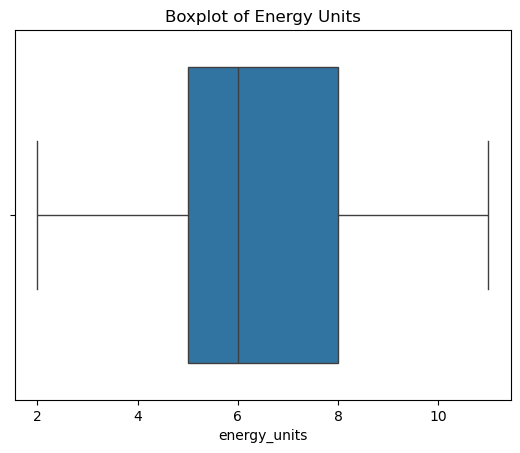

In [22]:
data=pd.read_csv(r"C:\Users\allad\ENERGYdataset.csv")
#data cleaning and ANALYSIS
print('Dataset information')
print(data.head())
print(data.shape)
print(data.info())
print('finding missing values\n',data.isnull().sum())
print('finding duplicates\n',data.duplicated().sum())
sns.boxplot(x=data['energy_units'])
plt.title("Boxplot of Energy Units")
plt.show()

In [19]:
#data splitting
X=data[['temperature','humidity','fans_on','ac_on','lights_on','weekend']]
y=data['energy_units']
x_train,x_test,y_train,y_test,=train_test_split(X,y,test_size=0.2,random_state=42)
#Model creation
model=LinearRegression()
#model training
model.fit(x_train,y_train)
#make predictions
y_pred=model.predict(x_test)
#calculate errors
mae=mean_absolute_error(y_test,y_pred)
r2score=r2_score(y_test,y_pred)
print('Mean absolute Error:',mae)
print('R2 score:',r2score)
res=pd.DataFrame({'Actual':y_test,
                 'Predicted':y_pred})
print(res.head(10))

Mean absolute Error: 0.48146892998583346
R2 score: 0.9097806305326224
     Actual  Predicted
521      10   9.787243
737       8   7.635916
740       8   7.383537
660       5   4.627579
411       8   6.992597
678       3   2.610337
626       8   8.329623
513      10   9.315151
859       8   8.306699
136       6   4.743458


In [20]:
#prediction on new data
new=pd.DataFrame({'temperature':[25],'humidity':[54], 'fans_on':[3], 'ac_on':[1], 'lights_on':[3], 'weekend':[1]})
print('New data\n',new)
predn=model.predict(new)
print('Predicted energy units are:',predn.round().astype(int))

New data
    temperature  humidity  fans_on  ac_on  lights_on  weekend
0           25        54        3      1          3        1
Predicted energy units are: [8]


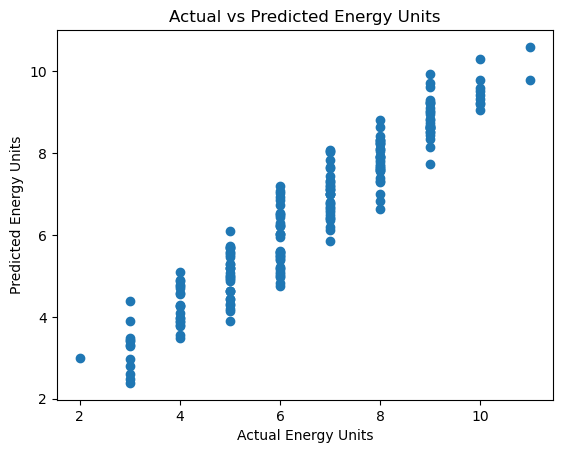

In [21]:
#plotting
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Energy Units")
plt.ylabel("Predicted Energy Units")
plt.title("Actual vs Predicted Energy Units")
plt.show()